# Plot viability per tumor type
Measured viability (% of that patient's DMSO) for each treatment, shown as a heatmap.
Rows are individual patients grouped by tumor type, with the tumor type mean as the last row of each group; columns are treatments.
The color scale is centered at 100% (equal to DMSO): red is lower viability, blue is higher.
Grey tiles are patient/treatment combinations that were not tested.
The PDF has two pages: page 1 shows all patients, including those without viability data; page 2 shows only patients with viability data.

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "arrow", "RColorBrewer")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(package, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE)
        )
    )
}

find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))
source(file.path(root_dir, "utils", "r_plot_funcs.r"))

In [2]:
results_dir <- file.path(root_dir, "5.differential_analysis", "results")
figures_dir <- file.path(root_dir, "5.differential_analysis", "figures")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

patient_viability_path <- file.path(results_dir, "viability_log2fc_by_patient_tumor_type.parquet")
tumor_type_viability_path <- file.path(results_dir, "viability_log2fc_by_tumor_type.parquet")
figure_path <- file.path(figures_dir, "viability_percent_by_tumor_type.pdf")

tumor_type_levels <- c("cNF", "pNF", "MPNST", "Other")

In [3]:
add_treatment_label <- function(df) {
    df %>%
        mutate(
            treatment_label = paste0(
                Metadata_Experiment_Treatment, " ",
                as.character(Metadata_Experiment_Dose), " ",
                Metadata_Experiment_Unit
            ),
            Metadata_Biology_TumorType = factor(
                Metadata_Biology_TumorType,
                levels = intersect(tumor_type_levels, unique(Metadata_Biology_TumorType))
            )
        )
}

patient_viability_df <- add_treatment_label(read_parquet(patient_viability_path))
tumor_type_viability_df <- add_treatment_label(read_parquet(tumor_type_viability_path))

treatment_label_levels <- patient_viability_df %>%
    distinct(Metadata_Experiment_Treatment, Metadata_Experiment_Dose, treatment_label) %>%
    arrange(match(Metadata_Experiment_Treatment, custom_treatment_order), Metadata_Experiment_Dose) %>%
    pull(treatment_label)
patient_viability_df$treatment_label <- factor(patient_viability_df$treatment_label, levels = treatment_label_levels)
tumor_type_viability_df$treatment_label <- factor(tumor_type_viability_df$treatment_label, levels = treatment_label_levels)
head(tumor_type_viability_df)

Metadata_Biology_TumorType,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Unit,n_patients,mean_viability_percent,sd_viability_percent,median_viability_percent,mean_viability_log2fc,sd_viability_log2fc,median_viability_log2fc,mean_viability_percent_of_dmso,treatment_label
<fct>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
MPNST,Binimetinib,1,uM,2,83.92627,7.926093,83.92627,-0.2560297,0.1364529,-0.2560297,83.73893,Binimetinib 1 uM
MPNST,Binimetinib,10,uM,2,84.24938,6.451367,84.24938,-0.2493799,0.1105820,-0.2493799,84.12579,Binimetinib 10 uM
MPNST,Cabozantinib,1,uM,2,93.85659,36.309614,93.85659,-0.1475759,0.5727072,-0.1475759,90.27661,Cabozantinib 1 uM
MPNST,Copanlisib,1,uM,2,56.30321,34.132582,56.30321,-0.9751748,0.9349855,-0.9751748,50.86782,Copanlisib 1 uM
MPNST,Digoxin,1,uM,2,30.38459,12.905965,30.38459,-1.7867836,0.6322824,-1.7867836,28.98175,Digoxin 1 uM
MPNST,Everolimus,1,uM,2,72.47430,13.982170,72.47430,-0.4780095,0.2800794,-0.4780095,71.79675,Everolimus 1 uM


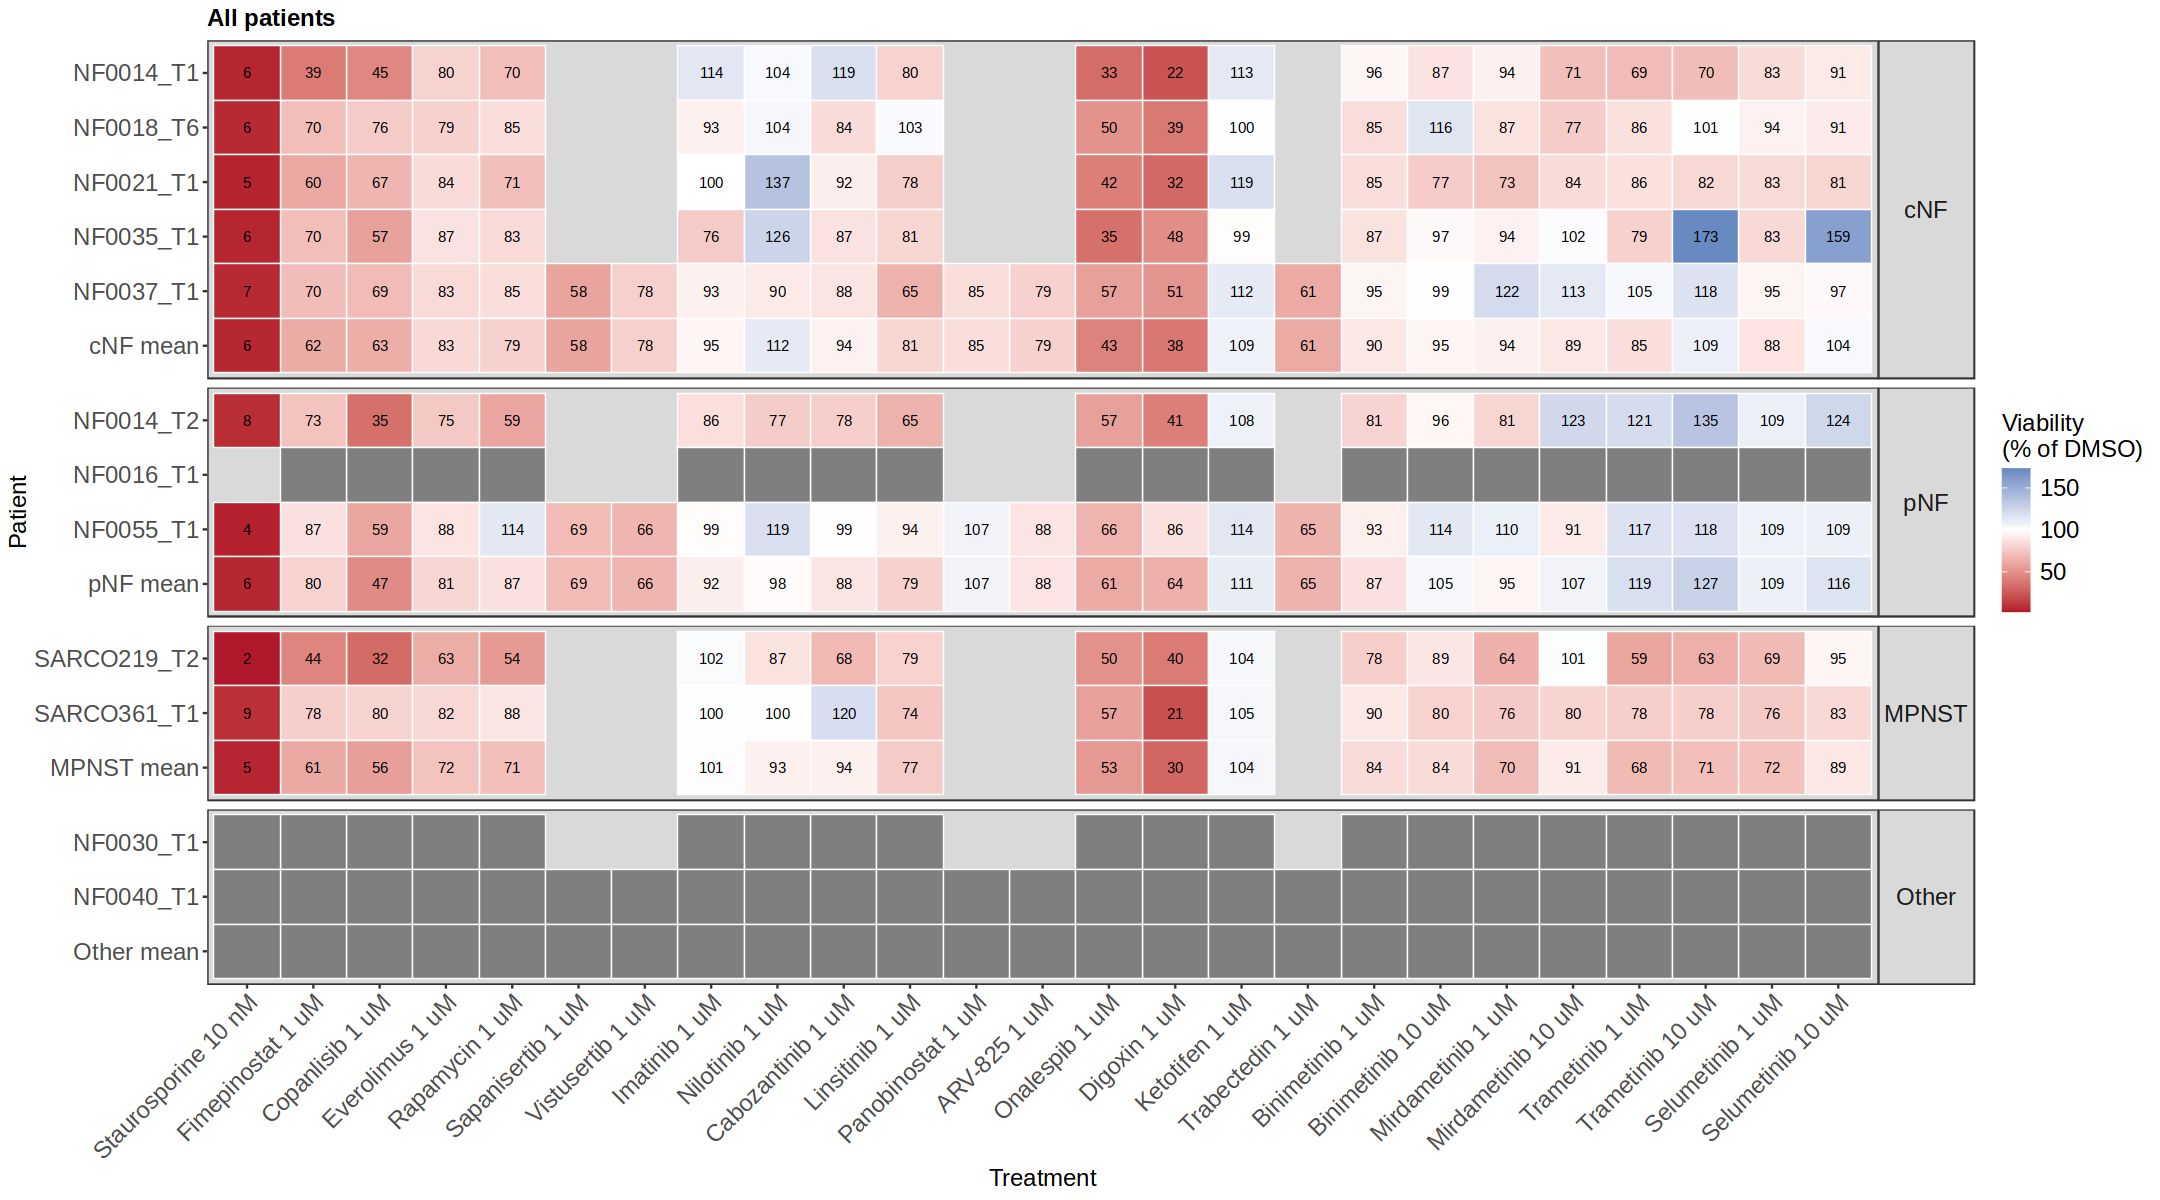

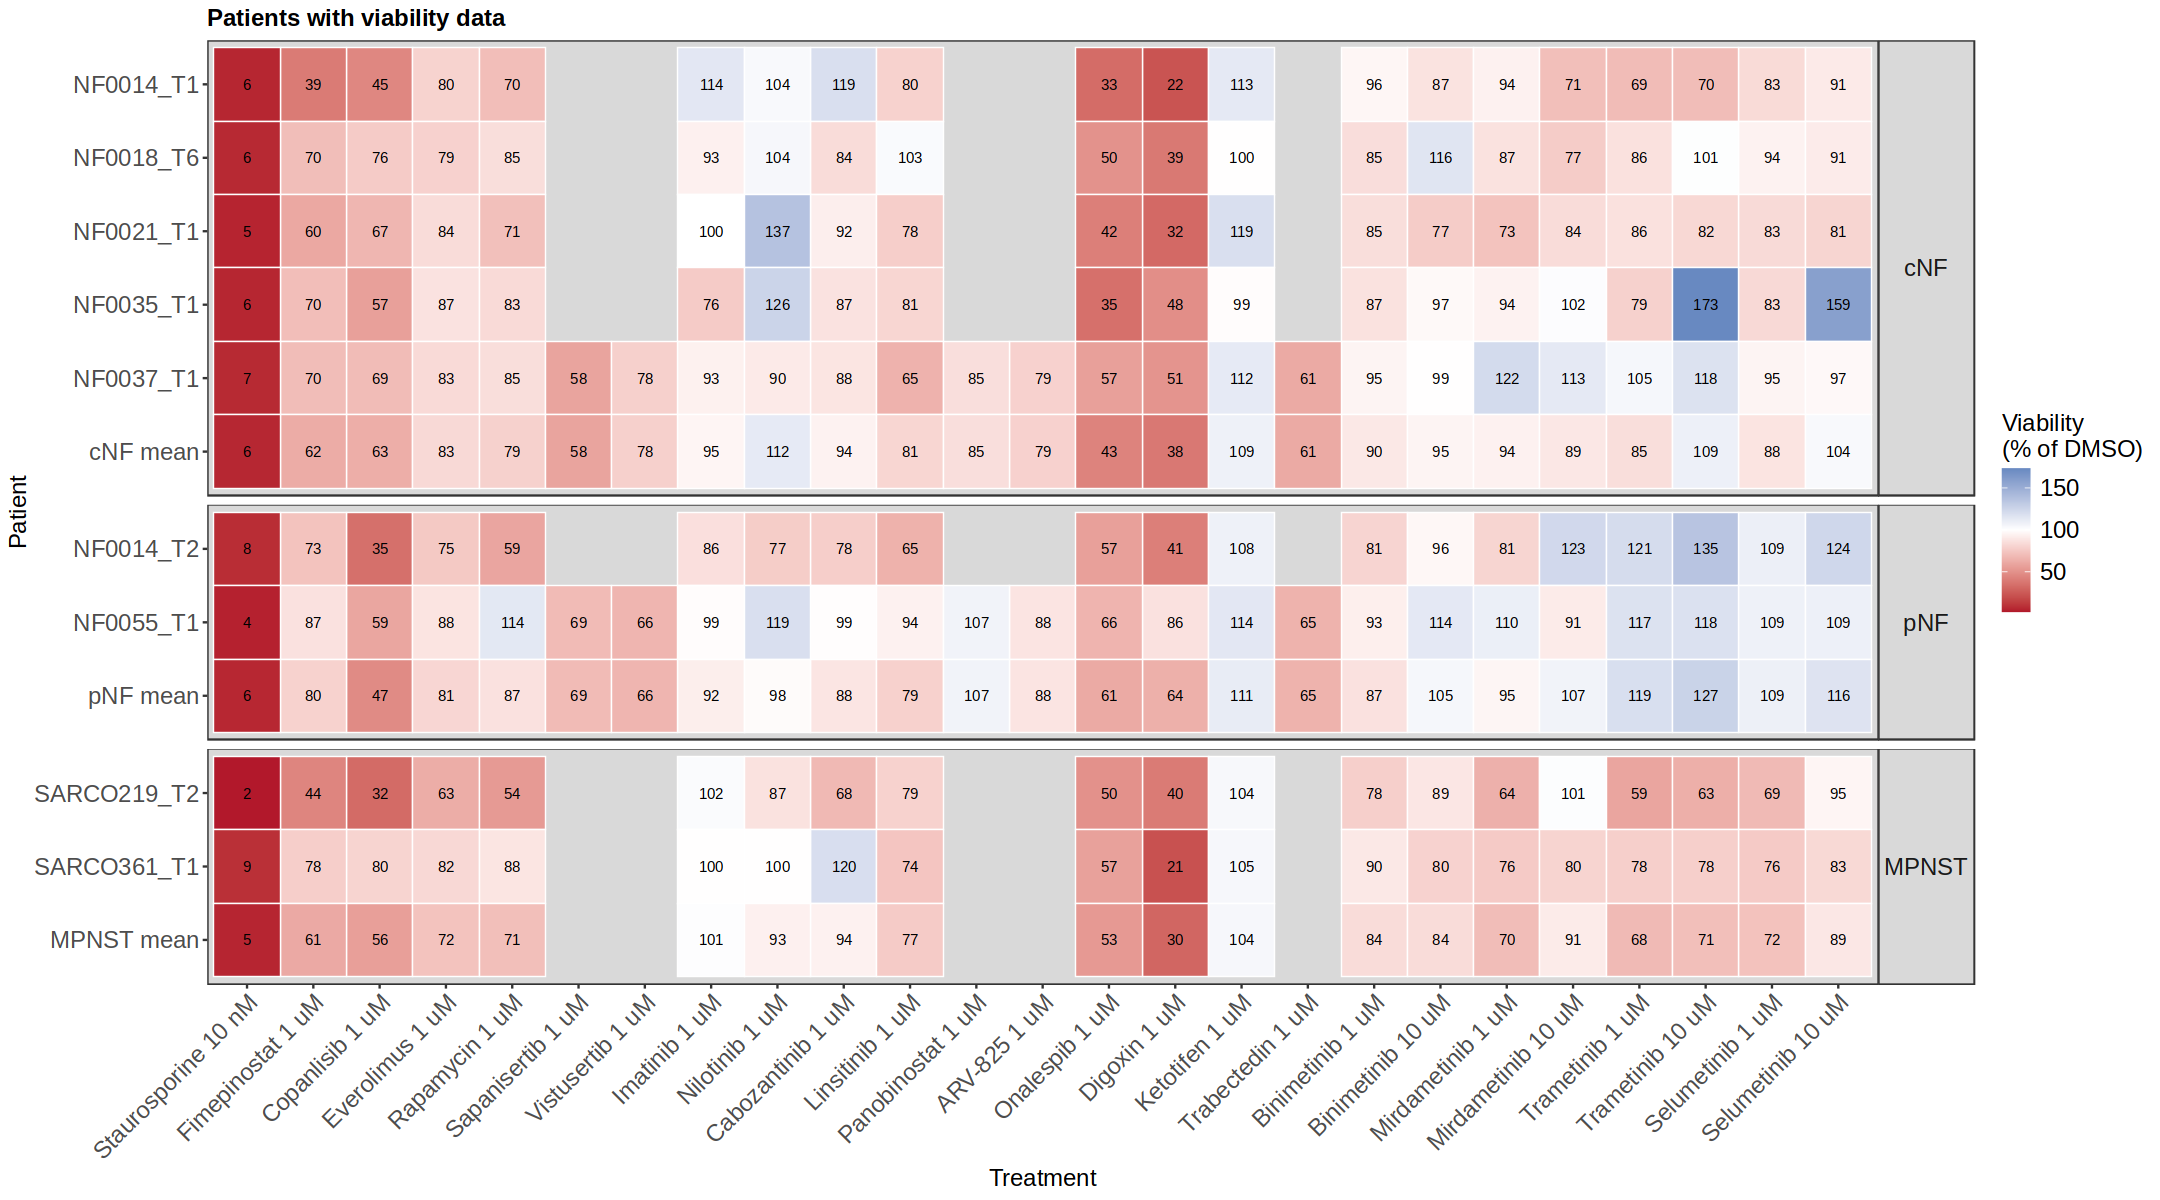

In [4]:
heatmap_df_from_tables <- function(patient_df, tumor_type_df) {
    bind_rows(
        patient_df %>%
            select(
                Metadata_Biology_TumorType,
                row_label = Metadata_Biology_PatientTumor,
                treatment_label,
                viability_percent = Metadata_Viability_Percentage
            ),
        tumor_type_df %>%
            transmute(
                Metadata_Biology_TumorType,
                row_label = paste0(Metadata_Biology_TumorType, " mean"),
                treatment_label,
                viability_percent = mean_viability_percent
            )
    )
}

make_viability_heatmap <- function(heatmap_df, title) {
    heatmap_df <- heatmap_df %>%
        mutate(Metadata_Biology_TumorType = droplevels(Metadata_Biology_TumorType))
    row_label_levels <- heatmap_df %>%
        distinct(Metadata_Biology_TumorType, row_label) %>%
        arrange(Metadata_Biology_TumorType, grepl(" mean$", row_label), row_label) %>%
        pull(row_label)
    heatmap_df$row_label <- factor(heatmap_df$row_label, levels = rev(row_label_levels))

    (
        ggplot(heatmap_df, aes(x = treatment_label, y = row_label, fill = viability_percent))
        + geom_tile(color = "white", linewidth = 0.3)
        + geom_text(
            data = filter(heatmap_df, !is.na(viability_percent)),
            aes(label = round(viability_percent)),
            size = 3
        )
        + scale_fill_gradient2(
            low = "#b2182b",
            mid = "white",
            high = "#2166ac",
            midpoint = 100,
            name = "Viability\n(% of DMSO)"
        )
        + facet_grid(Metadata_Biology_TumorType ~ ., scales = "free_y", space = "free_y")
        + labs(title = title, x = "Treatment", y = "Patient")
        + theme_manuscript(base_size = 14)
        + theme(
            axis.text.x = element_text(angle = 45, hjust = 1),
            panel.grid = element_blank(),
            panel.background = element_rect(fill = "grey85"),
            strip.text.y = element_text(angle = 0)
        )
    )
}

# page 1: every patient, including those without viability data (grey tiles)
all_heatmap_df <- heatmap_df_from_tables(patient_viability_df, tumor_type_viability_df)

# page 2: only patients with viability data, and only tumor types that have some
tested_heatmap_df <- heatmap_df_from_tables(
    patient_viability_df %>% filter(!is.na(Metadata_Viability_Percentage)),
    tumor_type_viability_df %>% filter(n_patients > 0)
)

options(repr.plot.width = 18, repr.plot.height = 10)
viability_all_plot <- make_viability_heatmap(all_heatmap_df, "All patients")
viability_tested_plot <- make_viability_heatmap(tested_heatmap_df, "Patients with viability data")
save_plots_pdf(
    list(viability_all_plot, viability_tested_plot),
    figure_path,
    width = 18,
    height = 10
)
viability_all_plot
viability_tested_plot